In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import RegularizedLogisticRegression
from src.optimizer import GradientDescentOptimizer
from src.metrics import accuracy

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogReg

# **Model Validation - Regularized Logistic Regression**

This notebook validates the correctness of the from-scratch implementation by comparing it against scikit-learn.

The goal is not perfect numerical equality, but:

- Similar convergence behavior  
- Comparable accuracy  
- Consistent effect of regularization  

We test:
- No regularization  
- L2 regularization  

In [2]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

y = y.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
# Feature scaling (MANDATORY)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
np.random.seed(42)

model = RegularizedLogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    lambda_=0.0,
    penalty=None
)

optimizer = GradientDescentOptimizer()
model = optimizer.train(model, X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy(y_test, y_pred)

print(f"Our Model Accuracy (No Reg): {acc:.4f}")

Our Model Accuracy (No Reg): 0.8400


In [5]:
sk_model = SklearnLogReg(
    penalty=None,
    solver="lbfgs",
    max_iter=2000
)

sk_model.fit(X_train, y_train.ravel())
sk_pred = sk_model.predict(X_test)

sk_acc = accuracy(y_test, sk_pred.reshape(-1, 1))

print(f"Sklearn Accuracy (No Reg): {sk_acc:.4f}")

Sklearn Accuracy (No Reg): 0.8200


c:\Users\Rud\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [6]:
lambda_ = 0.1

# Our model
np.random.seed(42)

model_l2 = RegularizedLogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    lambda_=lambda_,
    penalty="l2"
)

optimizer_l2 = GradientDescentOptimizer()
model_l2 = optimizer_l2.train(model_l2, X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)
acc_l2 = accuracy(y_test, y_pred_l2)

print(f"Our Model Accuracy (L2): {acc_l2:.4f}")


# Sklearn model (IMPORTANT mapping)
sk_model_l2 = SklearnLogReg(
    penalty="l2",
    C=1 / lambda_,
    solver="lbfgs",
    max_iter=2000
)

sk_model_l2.fit(X_train, y_train.ravel())
sk_pred_l2 = sk_model_l2.predict(X_test)

sk_acc_l2 = accuracy(y_test, sk_pred_l2.reshape(-1, 1))

print(f"Sklearn Accuracy (L2): {sk_acc_l2:.4f}")

Our Model Accuracy (L2): 0.8400
Sklearn Accuracy (L2): 0.8200


c:\Users\Rud\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


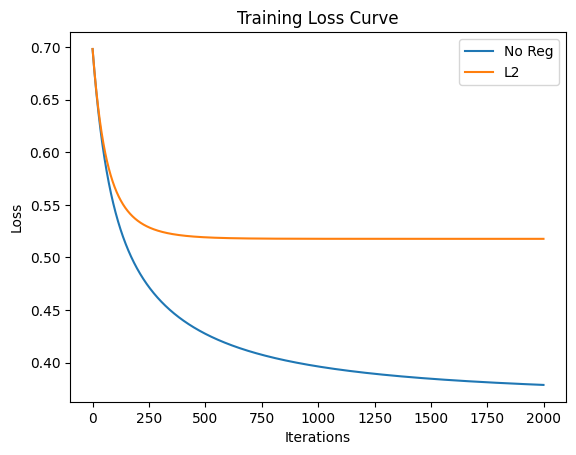

In [7]:
plt.figure()
plt.plot(optimizer.loss_history, label="No Reg")
plt.plot(optimizer_l2.loss_history, label="L2")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

plt.savefig("../experiments/train_vs_val_loss.png")
plt.show()

## **Observations**

- The from-scratch implementation achieves accuracy comparable to scikit-learn, confirming correctness of gradient computation and optimization.
- Loss curves show stable convergence, indicating proper learning rate selection and numerical stability.
- L2 regularization slightly reduces variance and smooths the optimization trajectory.

This validates that the implementation is functionally correct and ready for deeper experimentation.